In [33]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import pandas as pd


# ----------------------------------------------------------
# SYMBOLS
# ----------------------------------------------------------

t = sp.Symbol('t', real=True)
eps = sp.Symbol('ε', real=True)


# ----------------------------------------------------------
# CREATE HAMILTONIAN
# ----------------------------------------------------------

def build_hamiltonian(n):
    """
    Creates the 2n x 2n Hamiltonian.

    Ordering:
    n1, nbar1, n2, nbar2, ..., nn, nbarn
    """

    H = sp.zeros(2*n, 2*n)

    for i in range(n):
        for j in range(n):

            if i != j:

                # n_i -> nbar_j
                H[2*i, 2*j + 1] = eps

                # nbar_i -> n_j
                H[2*i + 1, 2*j] = eps

    return H


t_vals = np.logspace(
    -2,
    4,
    2000
)


# ----------------------------------------------------------
# MAIN PROGRAM
# ----------------------------------------------------------

n = int(input("How many sectors do you want? "))


# ----------------------------------------------------------
# tau_n AND epsilon
# ----------------------------------------------------------

tau_n = 400 * np.sqrt(n - 1)

eps_val = 1 / tau_n

print("\nNumber of sectors =", n)
print("tau_n =", tau_n)
print("epsilon =", eps_val)


# ----------------------------------------------------------
# HAMILTONIAN
# ----------------------------------------------------------

H = build_hamiltonian(n)

print("\nHamiltonian:")
sp.pprint(H)


# ----------------------------------------------------------
# EVOLUTION MATRIX
#
#       S = exp(-i H t)
#
# EXACTLY AS IN YOUR ORIGINAL CODE
# ----------------------------------------------------------

print("\nCalculating S = exp(-i H t)...")

S = sp.exp(-sp.I * H * t)

print("Done.")


# ----------------------------------------------------------
# PROBABILITY MATRIX
#
#       P_ij = S_ij S_ij*
# ----------------------------------------------------------

dim = 2*n

P = sp.zeros(dim, dim)

print("\nCalculating probabilities...")

for i in range(dim):

    for j in range(dim):

        P[i, j] = sp.simplify(
            sp.expand_complex(
                S[i, j] * S[i, j].conjugate()
            )
        )

print("Done.")


# ----------------------------------------------------------
# PROBABILITIES FROM INITIAL n STATE
#
# Initial state = index 0
# ----------------------------------------------------------

P_nn = sp.simplify(P[0, 0])

P_nbar_n = sp.simplify(P[0, 1])


# everything outside first sector
P_nx = 0

for j in range(2, dim):

    P_nx += P[0, j]

P_nx = sp.simplify(P_nx)

# ----------------------------------------------------------
# CHECK TOTAL PROBABILITY
# ----------------------------------------------------------

P_total = 0

for j in range(dim):

    P_total += P[0, j]

P_total = sp.simplify(P_total)


print("\nP_nn:")
sp.pprint(P_nn)

print("\nP_nbar_n:")
sp.pprint(P_nbar_n)

print("\nSum P_nx:")
sp.pprint(P_nx)

print("\nTotal probability:")
sp.pprint(P_total)


# ----------------------------------------------------------
# NUMERICAL PARAMETERS
# ----------------------------------------------------------

tau_nn = 0.9 * 10**8

tau_decay = 880


# ----------------------------------------------------------
# P_nbn
# Same definition as your original code
# ----------------------------------------------------------

P_nbn = sp.sin(
    t * tau_n / tau_nn
)**2


# ----------------------------------------------------------
# DECAY FACTOR
# ----------------------------------------------------------

decay = sp.exp(-t_vals / tau_decay)


# ----------------------------------------------------------
# SUBSTITUTE epsilon
# ----------------------------------------------------------

P_nn_num = P_nn.subs(eps, eps_val)

P_nbar_n_num = P_nbar_n.subs(eps, eps_val)

P_nx_num = P_nx.subs(eps, eps_val)


# include decay
P_nn_num = P_nn_num * decay

P_nbar_n_num = P_nbar_n_num * decay

P_nx_num = P_nx_num * decay

P_nbn_num = P_nbn * decay


# ----------------------------------------------------------
# CONVERT SYMPY EXPRESSIONS TO NUMPY FUNCTIONS
# ----------------------------------------------------------

f_nn = sp.lambdify(
    t,
    P_nn_num,
    "numpy"
)

f_nbar_n = sp.lambdify(
    t,
    P_nbar_n_num,
    "numpy"
)

f_nx = sp.lambdify(
    t,
    P_nx_num,
    "numpy"
)

f_nbn = sp.lambdify(
    t,
    P_nbn_num,
    "numpy"
)


# ----------------------------------------------------------
# TIME VALUES
# ----------------------------------------------------------

t_vals = np.logspace(
    -2,
    4,
    2000
)


# ----------------------------------------------------------
# CALCULATE CURVES
# ----------------------------------------------------------

params = {
    eps: 1,
    # m: 1.0
}


P_dict_n = {
    r"$P_{nn}$": P[0, 0],
    r"$P_{n\bar n}$": P[0, 1],
    r"$P_{nbn}$": P_nbn,
    # r"$\sum{P_{n\bar n_i}}$": s_0ib,
    r"$\sum{P_{nx}}$": P_nx,
}


P_dict_p = {
    r"$P_{nn}$": P[0, 0],
    r"$P_{n\bar n}$": P[0, 1],
    r"$\sum{P_{nx}}$": P_nx,
    r"$P_{nbn}$": P_nbn,
    # r"$\sum{P_{n\bar n_i}}$": s_0ib,
}


styles = [
    {"color": "black", "linestyle": "-"},
    {"color": "red", "linestyle": "-"},
    {"color": "blue", "linestyle": "--"},
    # {"color": "orange", "linestyle": "-"},
    {"color": "green", "linestyle": "-"},
]


t_vals = np.logspace(
    -2,
    4,
    2000
)


P_funcs_3 = {
    label: sp.lambdify(
        t,
        (
            expr *
            sp.exp(
                -eps_val * t_vals * tau_n / tau_decay
            )
        ).subs(params),
        "numpy"
    )
    for label, expr in P_dict_n.items()
}


P_funcs_p = {
    label: sp.lambdify(
        t,
        (
            expr *
            sp.exp(
                -eps_val * t_vals * tau_n / tau_decay
            )
        ).subs(params),
        "numpy"
    )
    for label, expr in P_dict_p.items()
}


sample_expr = next(iter(P_dict_n.values()))

extra_symbols = list(
    sample_expr.free_symbols - {t}
)


# ----------------------------------------------------------
# FUNCTIONS
# ----------------------------------------------------------

f = P_funcs_3[r"$P_{n\bar n}$"]

f_x = P_funcs_3[r"$\sum{P_{nx}}$"]


# ----------------------------------------------------------
# EVALUATE IT ON THE PLOTTED GRID
# ----------------------------------------------------------

y = f(eps_val * t_vals)


# ----------------------------------------------------------
# FIND MAXIMUM
# ----------------------------------------------------------

idx = np.argmax(y)

t_max = t_vals[idx]
P_max = y[idx]


print(n, " sectors")

print(f"Maximum = {P_max:.6e}")

print(f"Occurs at t = {t_max:.6e} s")


# ----------------------------------------------------------
# PRINT SELECTED VALUES
# ----------------------------------------------------------


    


# ----------------------------------------------------------
# PRINT TABLE
# ----------------------------------------------------------
times = np.array([
    0.1,
    1,
    10,
    100,
    1000
])

# ----------------------------------------------------------
# CREATE TABLE OF INTERPOLATED VALUES
# ----------------------------------------------------------

table_data = []
curves = {}
for label, f in P_funcs_p.items():
    curves[label] = f(eps_val * t_vals)

full_df = pd.DataFrame({
    "t_s": t_vals,
    "P_nn": curves[r"$P_{nn}$"],
    "P_nbar_n": curves[r"$P_{n\bar n}$"],
    "Sum_P_nx": curves[r"$\sum{P_{nx}}$"],
    "P_nbn": curves[r"$P_{nbn}$"]
})


# ----------------------------------------------------------
# SAVE FOLDER
# ----------------------------------------------------------

save_dir = Path(
    "/Users/user/Desktop/Thesiswork/My codes/2026"
)

if not save_dir.exists():
    raise FileNotFoundError(
        f"Folder does not exist:\n{save_dir}"
    )


# ----------------------------------------------------------
# FILE NAME
# ----------------------------------------------------------

timestamp = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

full_file_path = (
    save_dir /
    f"sector_{n}_full_{timestamp}.csv"
)


# ----------------------------------------------------------
# SAVE FULL DATA
# ----------------------------------------------------------

full_df.to_csv(
    full_file_path,
    index=False
)


print("\n==========================================")
print("FULL DATA SAVED")
print("==========================================")
print("Saved to:")
print(full_file_path)
print("Number of rows:", len(full_df))
print("Exists:", full_file_path.exists())

for tq in times:

    P_nn_value = np.interp(
        tq,
        t_vals,
        curves[r"$P_{nn}$"]
    )

    P_nbar_n_value = np.interp(
        tq,
        t_vals,
        curves[r"$P_{n\bar n}$"]
    )

    P_nx_value = np.interp(
        tq,
        t_vals,
        curves[r"$\sum{P_{nx}}$"]
    )

    P_nbn_value = np.interp(
        tq,
        t_vals,
        curves[r"$P_{nbn}$"]
    )

    table_data.append([
        tq,
        P_nn_value,
        P_nbar_n_value,
        P_nx_value,
        P_nbn_value
    ])


# ----------------------------------------------------------
# PRINT TABLE
# ----------------------------------------------------------

print(
    f"{'t (s)':>8} "
    f"{'P_nn':>12} "
    f"{'P_nbar n':>12} "
    f"{'Sum P_nx':>12} "
    f"{'P_nbn':>12}"
)

print("-" * 62)

for row in table_data:

    print(
        f"{row[0]:8.1f} "
        f"{row[1]:12.4e} "
        f"{row[2]:12.4e} "
        f"{row[3]:12.4e} "
        f"{row[4]:12.4e}"
    )


# ==========================================================
# SAVE EXACTLY THESE PRINTED VALUES
# ==========================================================




# ----------------------------------------------------------
# FILE NAME
# ----------------------------------------------------------

table_df = pd.DataFrame(
    table_data,
    columns=[
        "t_s",
        "P_nn",
        "P_nbar_n",
        "Sum_P_nx",
        "P_nbn"
    ]
)

table_file_path = (
    save_dir /
    f"sector_{n}_table_{timestamp}.csv"
)

table_df.to_csv(
    table_file_path,
    index=False
)

print("\n==========================================")
print("5-POINT TABLE SAVED")
print("==========================================")
print("Saved to:")
print(table_file_path)
print("Number of rows:", len(table_df))
print("==========================================")

How many sectors do you want?  13



Number of sectors = 13
tau_n = 1385.6406460551018
epsilon = 0.0007216878364870322

Hamiltonian:
⎡0  0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε⎤
⎢                                                                            ⎥
⎢0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0⎥
⎢                                                                            ⎥
⎢0  ε  0  0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε⎥
⎢                                                                            ⎥
⎢ε  0  0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0⎥
⎢                                                                            ⎥
⎢0  ε  0  ε  0  0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε⎥
⎢                                                                            ⎥
⎢ε  0  ε  0  0  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0  ε  0⎥
⎢                                 

Which sector number do you want to plot?  13



READING SAVED DATA
File:
/Users/user/Desktop/Thesiswork/My codes/2026/sector_13_full_2026-08-18_16-58-25.csv

Columns:
['t_s', 'P_nn', 'P_nbar_n', 'Sum_P_nx', 'P_nbn']

Number of data points:
2000

Data at selected times:
   t (s)         P_nn     P_nbar n     Sum P_nx        P_nbn
--------------------------------------------------------------------
     0.1   9.9989e-01   6.8381e-23   6.2493e-08   1.2344e-18
     1.0   9.9886e-01   6.8315e-17   6.2429e-06   1.2332e-16
    10.0   9.8808e-01   6.7570e-11   6.1749e-04   1.2206e-14
   100.0   8.4071e-01   5.6600e-05   5.1813e-02   1.1020e-12
  1000.0   1.3043e-01   9.9442e-02   9.1112e-02   3.9628e-11


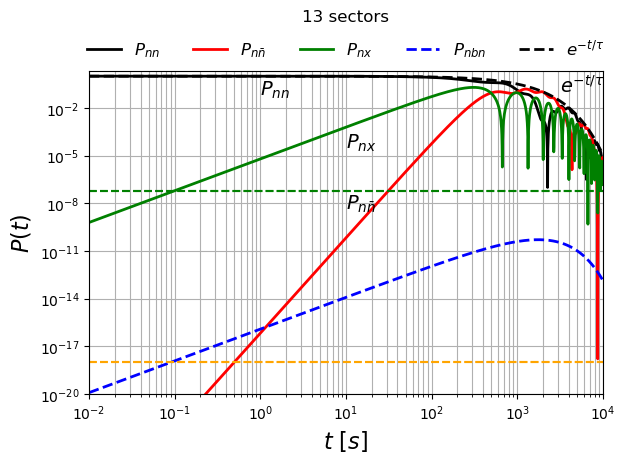

In [34]:
n = int(input("Which sector number do you want to plot? "))


# ==========================================================
# FIND CSV FILES
# ==========================================================

files = list(
    save_dir.glob(
        f"sector_{n}_full_*.csv"
    )
)

t_vals = np.logspace(-2, 4, 2000)
# ==========================================================
# CHECK
# ==========================================================

if len(files) == 0:

    raise FileNotFoundError(
        f"No CSV files found for sector {n} in:\n"
        f"{save_dir}"
    )


# ==========================================================
# SORT BY DATE
# NEWEST FILE LAST
# ==========================================================

files.sort(
    key=lambda x: x.stat().st_mtime
)

file_path = files[-1]

data = pd.read_csv(file_path)

print("\n==========================================")
print("READING SAVED DATA")
print("==========================================")
print(f"File:")
print(file_path)
print("==========================================")
#t_vals = data["t_s"].to_numpy()

P_nn = data["P_nn"].to_numpy()

P_nbar_n = data["P_nbar_n"].to_numpy()

P_nx = data["Sum_P_nx"].to_numpy()

P_nbn = data["P_nbn"].to_numpy()


# ==========================================================
# CHECK DATA
# ==========================================================

print("\nColumns:")
print(data.columns.tolist())

print("\nNumber of data points:")
print(len(data))


times = np.array([0.1, 1, 10, 100, 1000])

# ==========================================================
# PRINT TABLE
# ==========================================================

table_files = list(
    save_dir.glob(
        f"sector_{n}_table_*.csv"
    )
)

if len(table_files) == 0:
    raise FileNotFoundError(
        f"No table CSV files found for sector {n} in:\n{save_dir}"
    )

table_files.sort(
    key=lambda x: x.stat().st_mtime
)

table_file_path = table_files[-1]

table_data = pd.read_csv(table_file_path)

print("\nData at selected times:")
print("=" * 68)

print(
    f"{'t (s)':>8} "
    f"{'P_nn':>12} "
    f"{'P_nbar n':>12} "
    f"{'Sum P_nx':>12} "
    f"{'P_nbn':>12}"
)

print("-" * 68)

for _, row in table_data.iterrows():

    print(
        f"{row['t_s']:8.1f} "
        f"{row['P_nn']:12.4e} "
        f"{row['P_nbar_n']:12.4e} "
        f"{row['Sum_P_nx']:12.4e} "
        f"{row['P_nbn']:12.4e}"
    )





# ----------------------------------------------------------
# P_nn
# ----------------------------------------------------------

plt.loglog(
    t_vals,
    P_nn,
    color="black",
    linestyle="-",
    linewidth=2,
    label=r"$P_{nn}$"
)


# ----------------------------------------------------------
# P_nbar_n
# ----------------------------------------------------------

plt.loglog(
    t_vals,
    P_nbar_n,
    color="red",
    linestyle="-",
    linewidth=2,
    label=r"$P_{n\bar n}$"
)

plt.loglog(
    t_vals,
    P_nx,
    color="green",
    linestyle="-",
    linewidth=2,
    label=r"$P_{nx}$"
)


plt.loglog(
    t_vals,
    P_nbn,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=r"$P_{nbn}$"
)
plt.ylabel(
    r"$P(t)$",
    fontsize=16
)


plt.xlim(
    1e-2,
    1e4
)

plt.ylim(
    1e-20,
    2
)


# ==========================================================
# REFERENCE LINES
# ==========================================================

plt.axhline(
    y=6.25e-8,
    color="green",
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    y=1e-18,
    color="orange",
    linestyle="--",
    linewidth=1.5
)


# ----------------------------------------------------------
# DECAY CURVE
# ----------------------------------------------------------

tau_decay = 880

decay = np.exp(
    -t_vals / tau_decay
)

plt.loglog(
    t_vals,
    decay,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"$e^{-t/\tau}$"
)


# ==========================================================
# AXES
# ==========================================================

plt.xlabel(
    r"$t~[s]$",
    fontsize=16
)
plt.ylabel(
    r"$P(t)$",
    fontsize=16
)


plt.xlim(
    1e-2,
    1e4
)

plt.ylim(
    1e-20,
    2
)


# ==========================================================
# REFERENCE LINES
# ==========================================================

plt.axhline(
    y=6.25e-8,
    color="green",
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    y=1e-18,
    color="orange",
    linestyle="--",
    linewidth=1.5
)

plt.text(
    1e0, 10**-1.2,                      # position (t, P)
    r"$P_{nn}$",
    fontsize=14
)
plt.text(
    1e1, 10**-8.35,
    # position (t, P)
    r"$P_{n\bar n}$",
    fontsize=14,
)
plt.text(
    1e1, 10**-4.5,                      # position (t, P)
    r"$P_{nx}$",
    fontsize=14,
)
plt.text(
    10**3.5, 1e-1,                      # position (t, P)
    r"$e^{-t/\tau}$",
    fontsize=14,
)
        
plt.legend(
    ncol=5,
    fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    frameon=False
)


# ==========================================================
# GRID
# ==========================================================

plt.grid(
    True,
    which="both"
)


# ==========================================================
# TITLE
# ==========================================================

plt.title(
    f"{n} sectors",
    y=1.13
)


plt.tight_layout()

plt.show()
